<a href="https://colab.research.google.com/github/mocodotempo/WeatherforecastingECMWF/blob/main/Temp850ECMWF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# ============================================================
# BLOCO 1: INSTALAÇÃO DE DEPENDÊNCIAS
# ============================================================
!pip install -q cfgrib xarray cartopy geopandas requests scipy matplotlib
print("Bibliotecas instaladas com sucesso!")

Bibliotecas instaladas com sucesso!


In [18]:
# ============================================================
# BLOCO 2: IMPORTAÇÕES E CONFIGURAÇÕES
# ============================================================
import os
import requests
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from datetime import datetime
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm

# Configurações de data e hora
data_rodada = '20260908'
rodada = '00'

ano_prev = 2026
mes_prev = 9
dia_prev = 11
hora_prev = 9

# Calcular Forecast Hour (FH)
rodada_dt = datetime.strptime(f'{data_rodada} {rodada}', '%Y%m%d %H')
prev_dt = datetime(ano_prev, mes_prev, dia_prev, hora_prev)

forecast_hour = int((prev_dt - rodada_dt).total_seconds() / 3600)
if forecast_hour <= 144:
    forecast_hour = round(forecast_hour / 3) * 3
else:
    forecast_hour = round(forecast_hour / 6) * 6

print(f'Forecast calculado: +{forecast_hour}h')

rodada_str = rodada_dt.strftime('%d/%m/%Y %H UTC')
prev_str = prev_dt.strftime('%d/%m/%Y %H UTC')

Forecast calculado: +81h


In [19]:
# ============================================================
# BLOCO 3: DOWNLOAD DO ARQUIVO ECMWF
# ============================================================
arquivo = f'{data_rodada}{rodada}0000-{forecast_hour}h-oper-fc.grib2'
base_url = f'https://data.ecmwf.int/forecasts/{data_rodada}/{rodada}z/ifs/0p25/oper/'
url = base_url + arquivo

baixar = False
if not os.path.exists(arquivo):
    baixar = True
elif os.path.getsize(arquivo) < 100000:
    print('Arquivo corrompido detectado. Removendo...')
    os.remove(arquivo)
    baixar = True

if baixar:
    print('Baixando ECMWF...')
    r = requests.get(url, timeout=60)
    print('Status:', r.status_code)

    if r.status_code != 200:
        raise Exception(f'Erro download ECMWF: {r.status_code}')

    if 'text/html' in r.headers.get('Content-Type', ''):
        raise Exception('Servidor retornou HTML ao invés de GRIB')

    with open(arquivo, 'wb') as f:
        f.write(r.content)
    print(f'Arquivo salvo: {arquivo} ({os.path.getsize(arquivo)/1e6:.1f} MB)')

In [20]:
# ============================================================
# BLOCO 4: ABERTURA OTIMIZADA E RECORTE ESPACIAL
# ============================================================
try:
    ds = xr.open_dataset(
        arquivo,
        engine='cfgrib',
        backend_kwargs={
            'filter_by_keys': {
                'typeOfLevel': 'isobaricInhPa',
                'level': 850,
                'shortName': 't'
            },
            # Leitura otimizada por indexação direta para poupar memória
            'indexpath': ''
        }
    )
except Exception as e:
    print(f'Erro cfgrib: {e}')
    if os.path.exists(arquivo):
        os.remove(arquivo)
    raise

# Recorte imediato para a América do Sul e conversão para Celsius
t850 = ds['t'].sel(
    longitude=slice(-95, -25),
    latitude=slice(15, -60)
) - 273.15

lats = t850.latitude.values
lons = t850.longitude.values

# Suavização leve com filtro gaussiano
temp = gaussian_filter(t850.values, sigma=0.6)

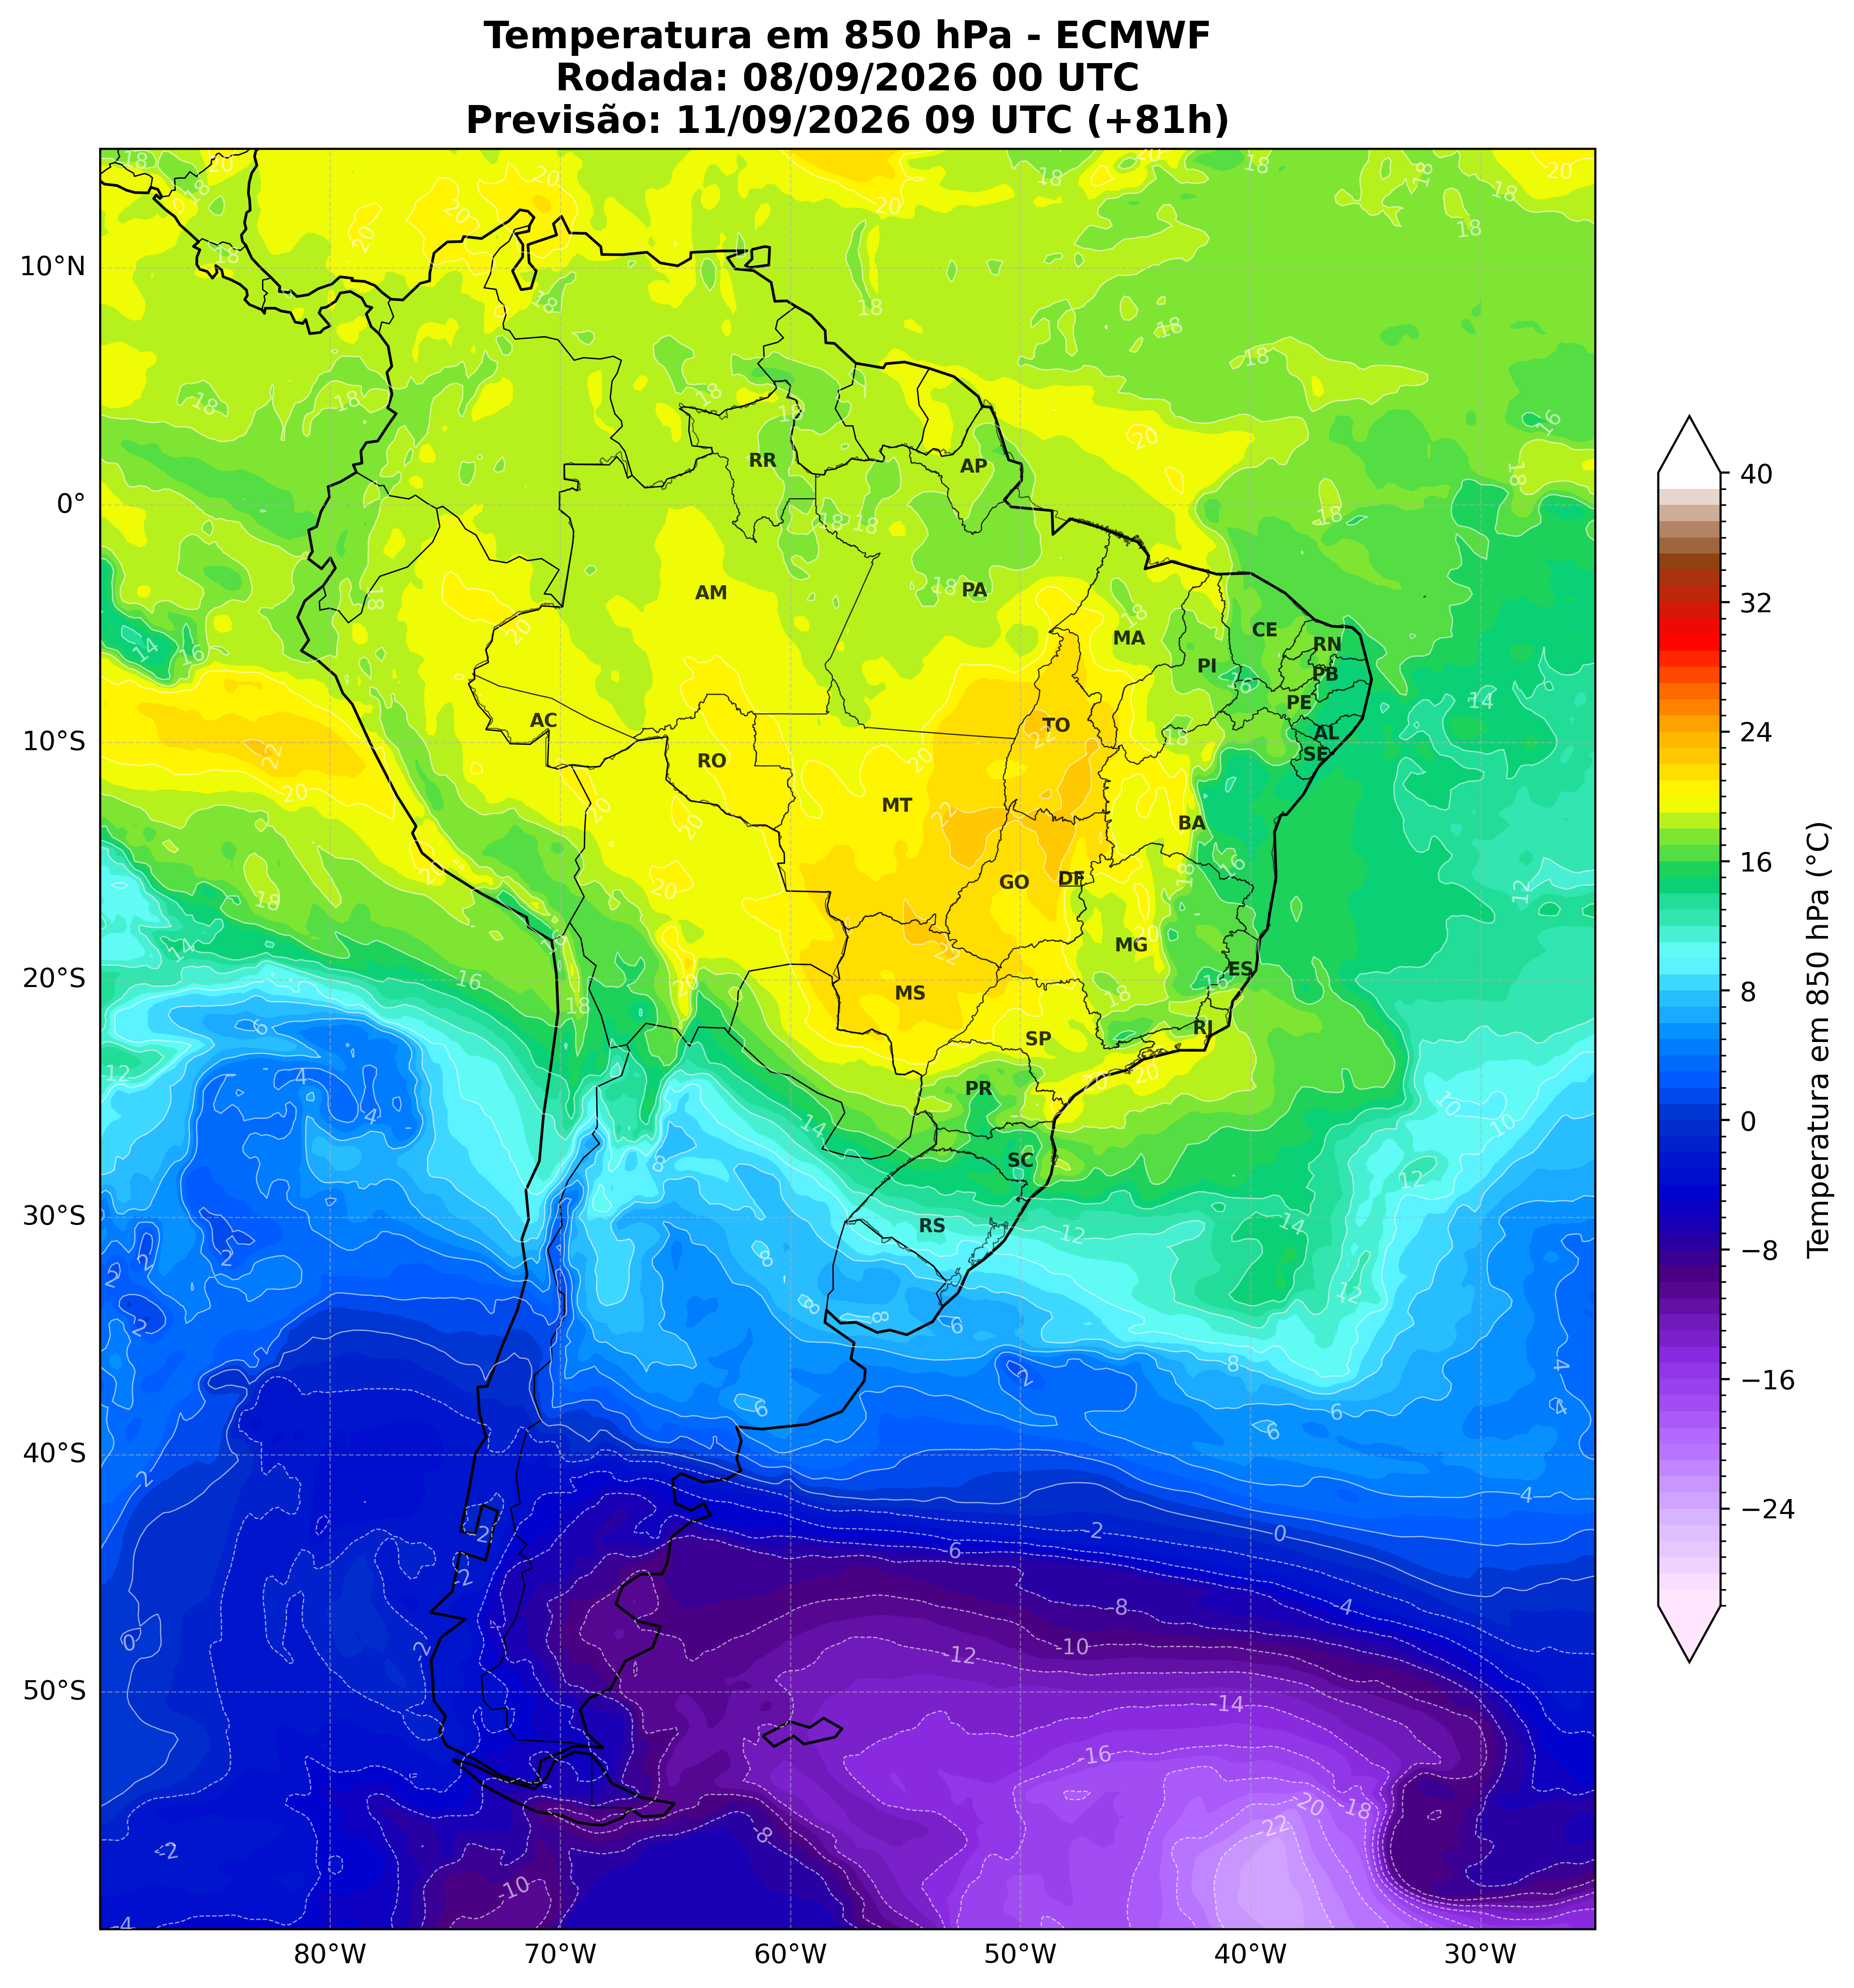

In [21]:
# ============================================================
# BLOCO 5: PLOTAGEM DO MAPA SINÓTICO
# ============================================================
levels = np.arange(-30, 41, 1)

colors_temp = [
    (-30, '#FFE6FF'), (-25, '#D6B3FF'), (-20, '#B266FF'), (-15, '#8A2BE2'),
    (-10, '#4B0082'), (-5, '#0000CD'), (0, '#0033CC'), (2, '#0055FF'),
    (5, '#0088FF'), (8, '#33CCFF'), (10, '#66FFFF'), (15, '#00CC66'),
    (20, '#FFFF00'), (25, '#FF9900'), (30, '#FF0000'), (35, '#8B4513'),
    (40, '#FFFFFF')
]

temps = [t for t, _ in colors_temp]
cols = [c for _, c in colors_temp]
pos = [(t - levels.min()) / (levels.max() - levels.min()) for t in temps]

cmap_temp = LinearSegmentedColormap.from_list('temp850', list(zip(pos, cols)))
norm_temp = BoundaryNorm(levels, cmap_temp.N)

# Criando a figura
fig = plt.figure(figsize=(14, 12),dpi=400)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-90, -25, -60, 15], crs=ccrs.PlateCarree())

# Preenchimento de temperatura
cf = ax.contourf(
    lons, lats, temp,
    levels=levels,
    cmap=cmap_temp,
    norm=norm_temp,
    extend='both',
    transform=ccrs.PlateCarree()
)

# Isotermas
iso_levels = np.arange(-30, 31, 2)
cs = ax.contour(
    lons, lats, temp,
    levels=iso_levels,
    colors='white',
    linewidths=0.45,
    alpha=0.6,
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, fmt='%d', fontsize=8, inline=True)

# Camadas de mapa base
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.15)
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# 7. LIMITES E SIGLAS DO BRASIL (BAIXANDO LOCALMENTE)

try:
    url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
    arquivo_br = "brazil-states.geojson"

    # Baixa o arquivo localmente para evitar conflitos de libcurl do GDAL
    if not os.path.exists(arquivo_br):
        r_br = requests.get(url_br, timeout=30)
        with open(arquivo_br, 'wb') as f:
            f.write(r_br.content)

    # Lê o arquivo do disco local
    br_states = gpd.read_file(arquivo_br)

    br_states.geometry.boundary.plot(
        ax=ax, color='black', linewidth=0.4, alpha=0.6, transform=ccrs.PlateCarree()
    )

    for geom, sigla in zip(br_states.geometry, br_states['sigla']):
        centroid = geom.representative_point()
        ax.text(
            centroid.x, centroid.y, sigla,
            fontsize=7, fontweight='bold', color='black', alpha=0.8,
            ha='center', va='center', transform=ccrs.PlateCarree()
        )
except Exception as e:
    print(f"Aviso: Não foi possível carregar as siglas dos estados. Erro: {e}")

# Grades e Coordenadas
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Barra de Cores
cbar = plt.colorbar(cf, ax=ax, shrink=0.7, pad=0.03)
cbar.set_label('Temperatura em 850 hPa (°C)', fontsize=11)

# Título
ax.set_title(
    f'Temperatura em 850 hPa - ECMWF\nRodada: {rodada_str}\nPrevisão: {prev_str} (+{forecast_hour}h)',
    fontsize=14, fontweight='bold'
)

plt.show()